# STEP 6 - Model Testing & Prediction

**Notebook:** `04_Model_Testing.ipynb` &nbsp;|&nbsp; **Model:** `models/accident_severity_model.pkl` (Step 5).

Evaluates the **saved** XGBoost model on the held-out 20% test set (same split as Step 5:
`test_size=0.2, stratify=y, random_state=42`) and predicts a completely new accident record.
**No re-fitting** of the model, scaler, or encoders happens anywhere in this notebook.

| Section | Content |
|---|---|
| 0 | Load saved artifacts & verify |
| 1 | Test set (split recreated, no fitting) |
| 2 | Evaluation: metrics + classification report |
| 3 | Confusion matrix (test) |
| 4 | Sample predictions with probabilities |
| 5 | Completely new accident record prediction |


## 0. Load Saved Artifacts


In [1]:
%matplotlib inline
import json, os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

def _find_root():
    d = os.getcwd()
    while True:
        if os.path.exists(os.path.join(d, "dataset", "processed_dataset.csv")):
            return d
        nd = os.path.dirname(d)
        if nd == d:
            break
        d = nd
    return os.path.abspath("..")

ROOT = _find_root()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from testing.test_model import (
    load_artifacts, load_test_data, preprocess_test_data,
    evaluate_model, predict_with_proba, print_prediction,
    predict_new_record, EXAMPLE_NEW_RECORD,
    save_test_confusion_matrix,
)
from utils.constants import TARGET_COLUMN, RANDOM_STATE, TEST_SIZE

artifacts = load_artifacts()
model, class_labels, feature_columns = (
    artifacts["model"], artifacts["class_labels"], artifacts["feature_columns"])
print("Model          :", type(model).__name__)
print("Class labels   :", class_labels)
print("Feature columns:", len(feature_columns))


2026-08-29 11:55:58 - RoadRiskAI - INFO - Loaded artifact -> model: C:\Users\suraj\Desktop\RoadRisk\models\accident_severity_model.pkl


2026-08-29 11:55:58 - RoadRiskAI - INFO - Loaded artifact -> feature_columns: C:\Users\suraj\Desktop\RoadRisk\models\feature_columns.pkl


2026-08-29 11:55:58 - RoadRiskAI - INFO - Loaded artifact -> scaler: C:\Users\suraj\Desktop\RoadRisk\models\scaler.pkl


2026-08-29 11:55:58 - RoadRiskAI - INFO - Loaded artifact -> label_encoders: C:\Users\suraj\Desktop\RoadRisk\models\label_encoders.pkl


2026-08-29 11:55:58 - RoadRiskAI - INFO - Class labels (from encoders): ['Slight Injury', 'Serious Injury', 'Fatal injury']


Model          : XGBClassifier
Class labels   : ['Slight Injury', 'Serious Injury', 'Fatal injury']
Feature columns: 165


## 1. Test Set (split recreated - NO fitting)


In [2]:
X_train, X_test, y_train, y_test = load_test_data()
X_test = preprocess_test_data(X_test, feature_columns)
print(f"Train: {X_train.shape[0]}  Test: {X_test.shape[0]}  Features: {X_test.shape[1]}")
print("Feature order matches model:",
      list(X_test.columns) == list(feature_columns))


2026-08-29 11:55:58 - RoadRiskAI - INFO - Loading dataset from: C:\Users\suraj\Desktop\RoadRisk\dataset\processed_dataset.csv


2026-08-29 11:55:58 - RoadRiskAI - INFO - Dataset loaded successfully with 12316 rows and 166 columns.


2026-08-29 11:55:58 - RoadRiskAI - INFO - Recreated Step 5 split: train=9852, test=2464 (random_state=42, test_size=0.2)


2026-08-29 11:55:58 - RoadRiskAI - INFO - Test set aligned to feature_columns: 165 features (order match: True)


Train: 9852  Test: 2464  Features: 165
Feature order matches model: True


## 2. Evaluation (weighted + macro; ROC-AUC OvR macro)


In [3]:
res = evaluate_model(model, X_test, y_test, class_labels)
m = res["metrics"]
print("=" * 58)
print("FINAL TEST METRICS")
print("=" * 58)
print(f"  Accuracy            : {m['accuracy']:.4f}")
print(f"  Precision (weighted): {m['precision_weighted']:.4f}   Precision (macro): {m['precision_macro']:.4f}")
print(f"  Recall    (weighted): {m['recall_weighted']:.4f}   Recall    (macro): {m['recall_macro']:.4f}")
print(f"  F1        (weighted): {m['f1_weighted']:.4f}   F1        (macro): {m['f1_macro']:.4f}")
print(f"  ROC-AUC (OvR macro) : {res['roc_auc']:.4f}")

print("\n" + "=" * 58)
print("CLASSIFICATION REPORT")
print("=" * 58)
print(res["classification_report"])


FINAL TEST METRICS
  Accuracy            : 0.8527
  Precision (weighted): 0.8209   Precision (macro): 0.8050
  Recall    (weighted): 0.8527   Recall    (macro): 0.4484
  F1        (weighted): 0.8129   F1        (macro): 0.5024
  ROC-AUC (OvR macro) : 0.7406

CLASSIFICATION REPORT
                precision    recall  f1-score   support

 Slight Injury     0.8633    0.9818    0.9187      2084
Serious Injury     0.5517    0.1375    0.2202       349
  Fatal injury     1.0000    0.2258    0.3684        31

      accuracy                         0.8527      2464
     macro avg     0.8050    0.4484    0.5024      2464
  weighted avg     0.8209    0.8527    0.8129      2464



## 3. Confusion Matrix (Test Set)


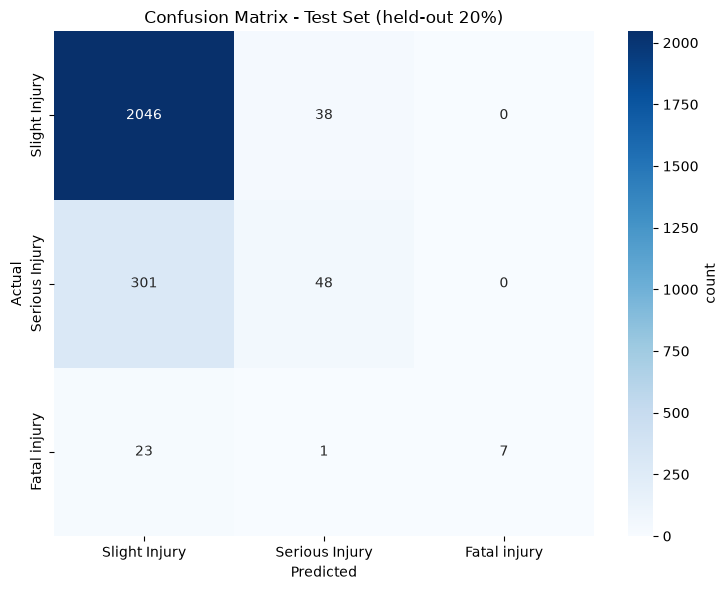

In [4]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, res["y_pred"])
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(pd.DataFrame(cm, index=class_labels, columns=class_labels),
            annot=True, fmt="d", cmap="Blues", ax=ax,
            cbar_kws={"label": "count"})
ax.set_title("Confusion Matrix - Test Set (held-out 20%)")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()


## 4. Sample Predictions with Probabilities (test set)


In [5]:
proba = model.predict_proba(X_test)
preds, _ = predict_with_proba(model, X_test, class_labels)
for i in range(5):
    actual = class_labels[int(y_test.iloc[i])]
    print_prediction(actual, preds[i], proba[i], class_labels)


  Actual   : Serious Injury
  Predicted: Slight Injury
  Probability:
    Slight Injury     67.4% <--
    Serious Injury    30.5%
    Fatal injury       2.1%
----------------------------------------
  Actual   : Serious Injury
  Predicted: Slight Injury
  Probability:
    Slight Injury     92.0% <--
    Serious Injury     7.4%
    Fatal injury       0.5%
----------------------------------------
  Actual   : Slight Injury
  Predicted: Slight Injury
  Probability:
    Slight Injury     62.8% <--
    Serious Injury    37.2%
    Fatal injury       0.0%
----------------------------------------
  Actual   : Serious Injury
  Predicted: Slight Injury
  Probability:
    Slight Injury     98.0% <--
    Serious Injury     2.0%
    Fatal injury       0.0%
----------------------------------------
  Actual   : Slight Injury
  Predicted: Slight Injury
  Probability:
    Slight Injury     99.1% <--
    Serious Injury     0.9%
    Fatal injury       0.0%
----------------------------------------


## 5. Completely New Accident Record

The record below is a **synthetic example** (clearly not real data) used to demonstrate the
prediction API. It is transformed using only the saved preprocessing artifacts &mdash;
the model/scaler/encoders are **never** re-fit.


In [6]:
print("New record (synthetic example - NOT real data):")
print(json.dumps(EXAMPLE_NEW_RECORD, indent=1))

label, proba_row, X_new = predict_new_record(EXAMPLE_NEW_RECORD, artifacts)
print(f"\nEncoded feature vector: {X_new.shape[1]} columns "
      f"(matches model: {X_new.shape[1] == len(feature_columns)})")
print_prediction("(no ground truth - new/unseen record)", label, proba_row, class_labels)


New record (synthetic example - NOT real data):
{
 "Time": "14:30:00",
 "Day_of_week": "Saturday",
 "Age_band_of_driver": "31-50",
 "Sex_of_driver": "Male",
 "Educational_level": "High school",
 "Vehicle_driver_relation": "Owner",
 "Driving_experience": "5-10yr",
 "Type_of_vehicle": "Automobile",
 "Owner_of_vehicle": "Owner",
 "Service_year_of_vehicle": "5-10yr",
 "Defect_of_vehicle": null,
 "Area_accident_occured": "Residential areas",
 "Lanes_or_Medians": "Two-way (divided with broken lines)",
 "Road_allignment": "Tangent road with flat terrain",
 "Types_of_Junction": "Y Shape",
 "Road_surface_type": "Asphalt roads",
 "Road_surface_conditions": "Dry",
 "Light_conditions": "Daylight",
 "Weather_conditions": "Normal",
 "Type_of_collision": "Vehicle with vehicle collision",
 "Number_of_vehicles_involved": 2,
 "Number_of_casualties": 1,
 "Vehicle_movement": "Going straight",
 "Casualty_class": "Driver or rider",
 "Sex_of_casualty": "Male",
 "Age_band_of_casualty": "31-50",
 "Casualty_sev

### Notes / Limitations
- Metrics reproduce the Step 5 report exactly (same data, same split, same model) &mdash; confirming no leakage.
- The class imbalance persists: `Slight Injury` recall is high while `Serious`/`Fatal` recall are low.
- The new-record prediction is purely illustrative; its probabilities reflect the model prior over
  the dominant class.
